# **Ensemble Learning (Bagging): -**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('/Users/yuvrajbhatkariya/Downloads/Practice_Datset/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [51]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [52]:
# df.isnull().sum()

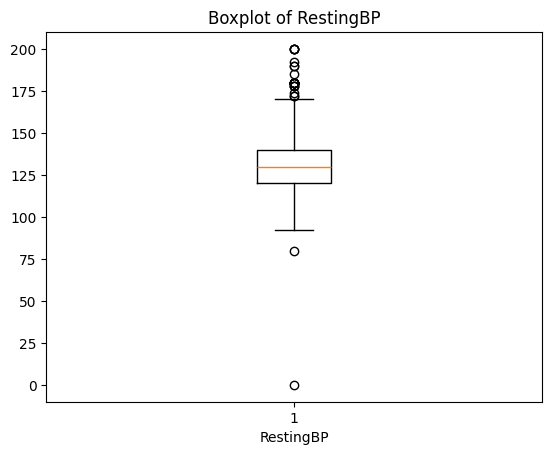

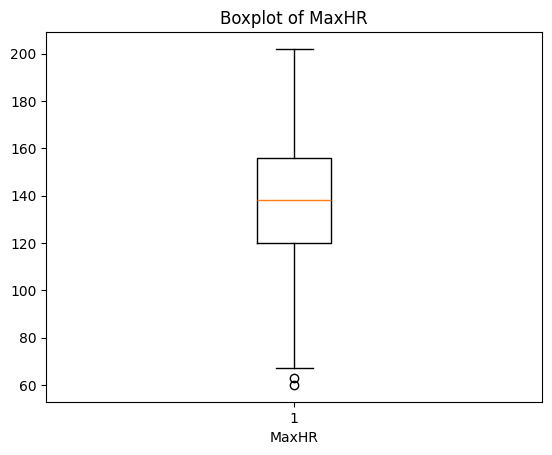

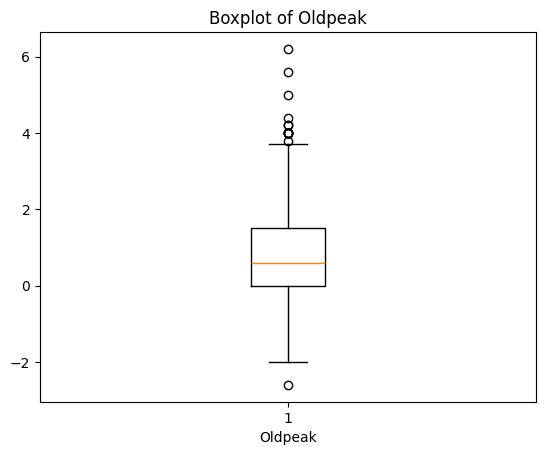

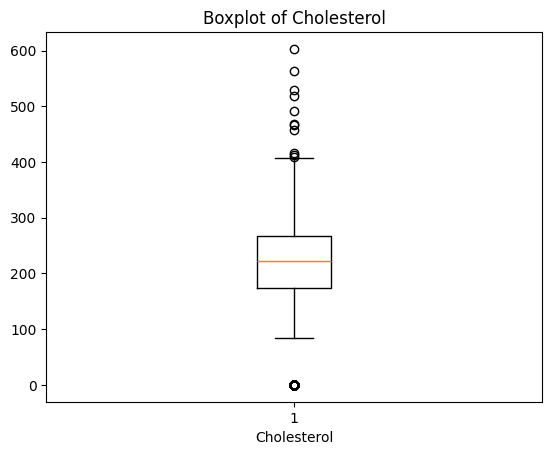

In [53]:
col = ['RestingBP','MaxHR','Oldpeak','Cholesterol']
for i in col:
    plt.figure()
    plt.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()

In [54]:
column = ['RestingBP','MaxHR','Oldpeak','Cholesterol']

for i in column:
    q1 = df[i].quantile(0.25)
    q2 = df[i].quantile(0.75)
    iqr = q2 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q2 + 1.5 * iqr
    df[i] = np.where(df[i]<lower_bound,df[i].median(),df[i])
    df[i] = np.where(df[i]>upper_bound,df[i].median(),df[i])


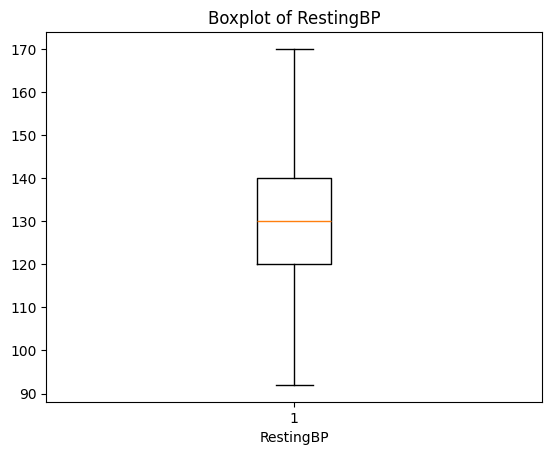

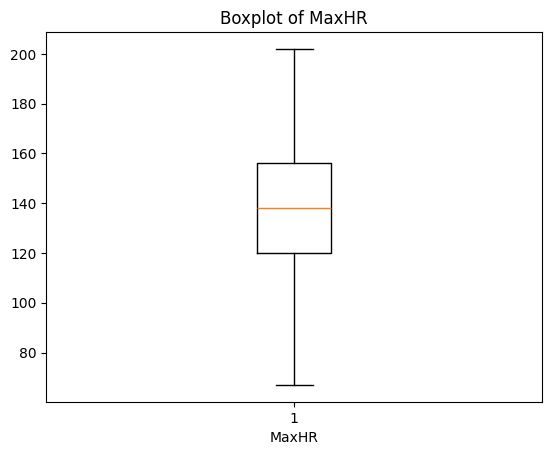

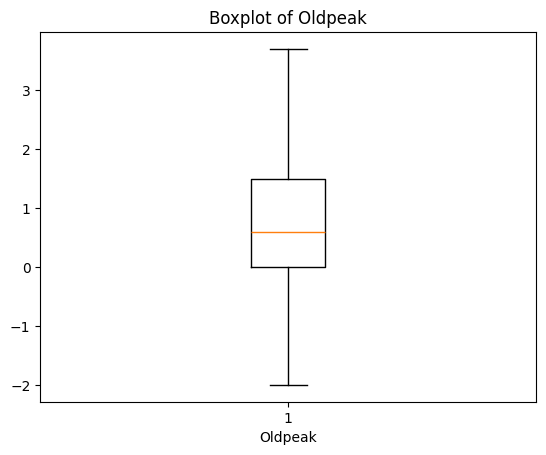

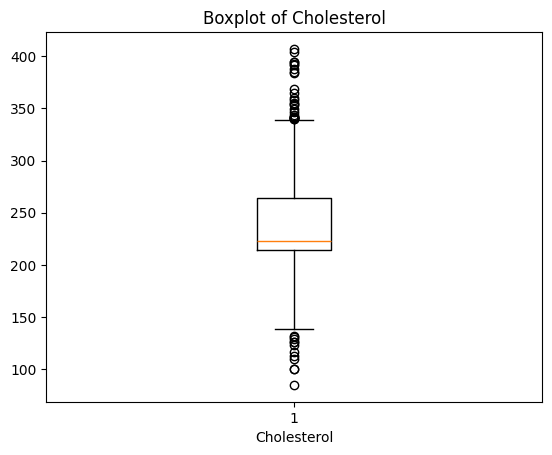

In [55]:
col1 = ['RestingBP','MaxHR','Oldpeak','Cholesterol']
for i in col1:
    plt.figure()
    plt.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()

In [56]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    float64
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172.0,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156.0,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98.0,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108.0,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122.0,N,0.0,Up,0


In [57]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [58]:
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(df,columns = ['Sex','ExerciseAngina'],drop_first = True)
df.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Oldpeak,ST_Slope,HeartDisease,Sex_M,ExerciseAngina_Y
0,40,ATA,140.0,289.0,0,Normal,172.0,0.0,Up,0,True,False
1,49,NAP,160.0,180.0,0,Normal,156.0,1.0,Flat,1,False,False
2,37,ATA,130.0,283.0,0,ST,98.0,0.0,Up,0,True,False
3,48,ASY,138.0,214.0,0,Normal,108.0,1.5,Flat,1,False,True
4,54,NAP,150.0,195.0,0,Normal,122.0,0.0,Up,0,True,False


In [59]:
from sklearn.preprocessing import LabelEncoder
le =  LabelEncoder()
for i in ['ChestPainType','RestingECG','ST_Slope']:
    df[i] = le.fit_transform(df[i])
df.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Oldpeak,ST_Slope,HeartDisease,Sex_M,ExerciseAngina_Y
0,40,1,140.0,289.0,0,1,172.0,0.0,2,0,True,False
1,49,2,160.0,180.0,0,1,156.0,1.0,1,1,False,False
2,37,1,130.0,283.0,0,2,98.0,0.0,2,0,True,False
3,48,0,138.0,214.0,0,1,108.0,1.5,1,1,False,True
4,54,2,150.0,195.0,0,1,122.0,0.0,2,0,True,False


In [60]:
df.HeartDisease.value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [61]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
col = [['RestingBP','Cholesterol','MaxHR','Age']]
for i in col:
    df[i] = scale.fit_transform(df[i])
df.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Oldpeak,ST_Slope,HeartDisease,Sex_M,ExerciseAngina_Y
0,-1.433140,1,0.572240,1.113204,0,1,1.389734,0.0,2,0,True,False
1,-0.478484,2,1.855220,-1.240259,0,1,0.754862,1.0,1,1,False,False
2,-1.751359,1,-0.069250,0.983655,0,2,-1.546550,0.0,2,0,True,False
3,-0.584556,0,0.443942,-0.506151,0,1,-1.149755,1.5,1,1,False,True
4,0.051881,2,1.213730,-0.916388,0,1,-0.594242,0.0,2,0,True,False


In [62]:
X = df.drop('HeartDisease',axis = 1)
Y = df['HeartDisease']

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
x_trian,x_test,y_trian,y_test = train_test_split(X,Y,test_size=0.2)
LR = LogisticRegression()

LR.fit(x_trian,y_trian)

LogisticRegression()

In [64]:
y_pred = LR.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8206521739130435

In [65]:
X = df.drop('HeartDisease',axis = 1)
Y = df['HeartDisease']
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

### **using Bagging : -**

In [66]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

bag_model = BaggingClassifier(
    estimator = LogisticRegression(),
    n_estimators = 100,
    max_samples = 0.8,
    oob_score = True,
    random_state = 0
)

score = cross_val_score(bag_model,X,Y,cv = 5)
score

array([0.8423913 , 0.8423913 , 0.8423913 , 0.84153005, 0.75409836])

In [67]:
X = df.drop('HeartDisease',axis = 1)
Y = df['HeartDisease']
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [68]:
bag_model.fit(x_trian,y_train)
bag_model.oob_score_

0.5599455040871935

In [69]:
pre = bag_model.predict(x_test)
accu = accuracy_score(y_test,pre)
accu

0.45108695652173914